In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Conexión del proyecto
from scripts.database import engine

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

QUERY = """
SELECT
    nombre,
    fecha_lanzamiento,
    rating,
    metacritic
FROM videojuegos_top
ORDER BY fecha_lanzamiento
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 20
   Columnas : 4


,nombre,fecha_lanzamiento,rating,metacritic
0,Grand Theft Auto: San Andreas,2004-10-26,4.50,93.0
1,Half-Life 2,2004-11-16,4.48,96.0
2,BioShock,2007-08-21,4.36,96.0
3,Portal,2007-10-09,4.49,90.0
4,Grand Theft Auto IV,2008-04-29,4.26,95.0


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────

df["fecha_lanzamiento"] = pd.to_datetime(df["fecha_lanzamiento"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["metacritic"] = pd.to_numeric(df["metacritic"], errors="coerce")

print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🎮 Juegos en el dataset:")
print(df["nombre"].nunique())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   nombre             20 non-null     object        
 1   fecha_lanzamiento  20 non-null     datetime64[ns]
 2   rating             20 non-null     float64       
 3   metacritic         20 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 772.0+ bytes
None

📊 Valores nulos por columna:
nombre               0
fecha_lanzamiento    0
rating               0
metacritic           0
dtype: int64

🎮 Juegos en el dataset:
20


In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = ["rating", "metacritic"]

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       rating  metacritic
count   20.00       20.00
mean     4.40       90.70
std      0.14        5.72
min      4.16       73.00
25%      4.27       88.75
50%      4.39       92.00
75%      4.49       94.25
max      4.64       96.00


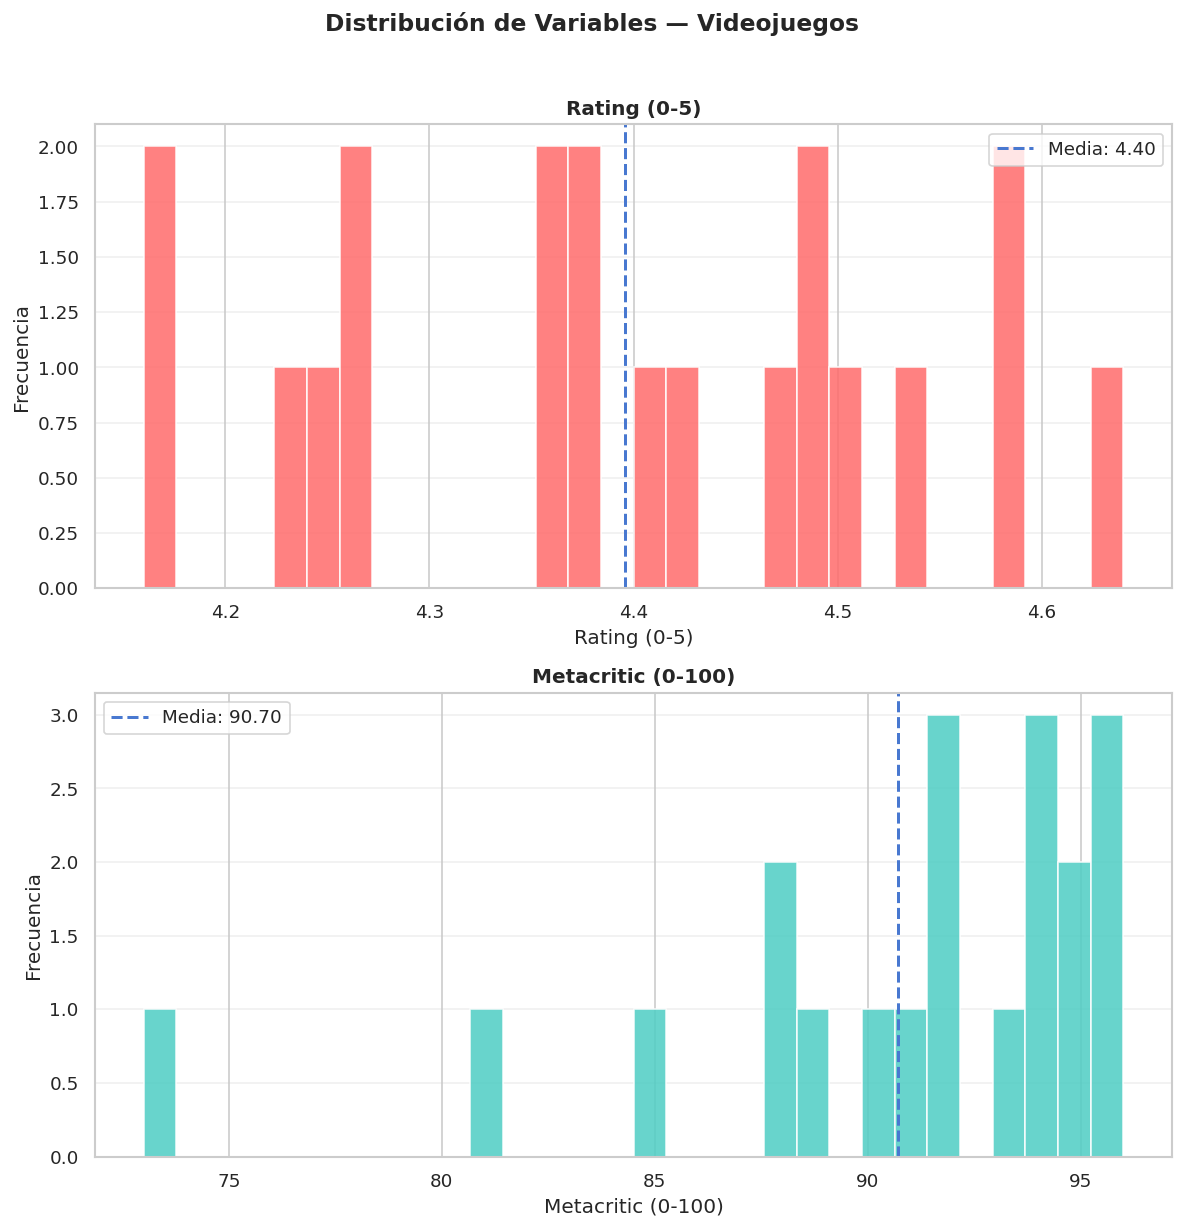

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

fig.suptitle('Distribución de Variables — Videojuegos',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'rating':     ('Rating (0-5)', '#ff6b6b'),
    'metacritic': ('Metacritic (0-100)', '#4ecdc4'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    valores = df[col].dropna()

    ax.hist(valores, bins=30, color=color, edgecolor='white', alpha=0.85)

    media = valores.mean()
    ax.axvline(media, linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/eda_distribuciones.png',
            dpi=150, bbox_inches='tight')

plt.show()

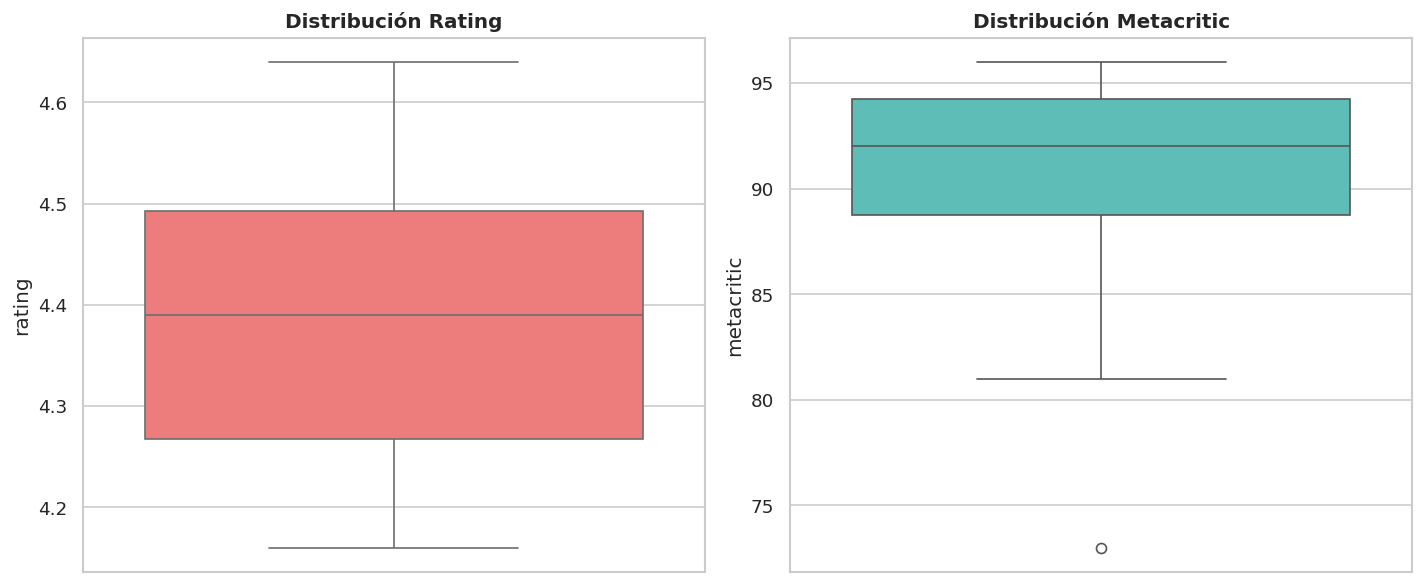

In [6]:
# ── CELDA 6: Boxplots ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='rating', ax=axes[0], color="#ff6b6b")
axes[0].set_title('Distribución Rating', fontweight='bold')

sns.boxplot(data=df, y='metacritic', ax=axes[1], color="#4ecdc4")
axes[1].set_title('Distribución Metacritic', fontweight='bold')

plt.tight_layout()

plt.savefig('../data/graficas/eda_boxplots.png',
            dpi=150, bbox_inches='tight')

plt.show()

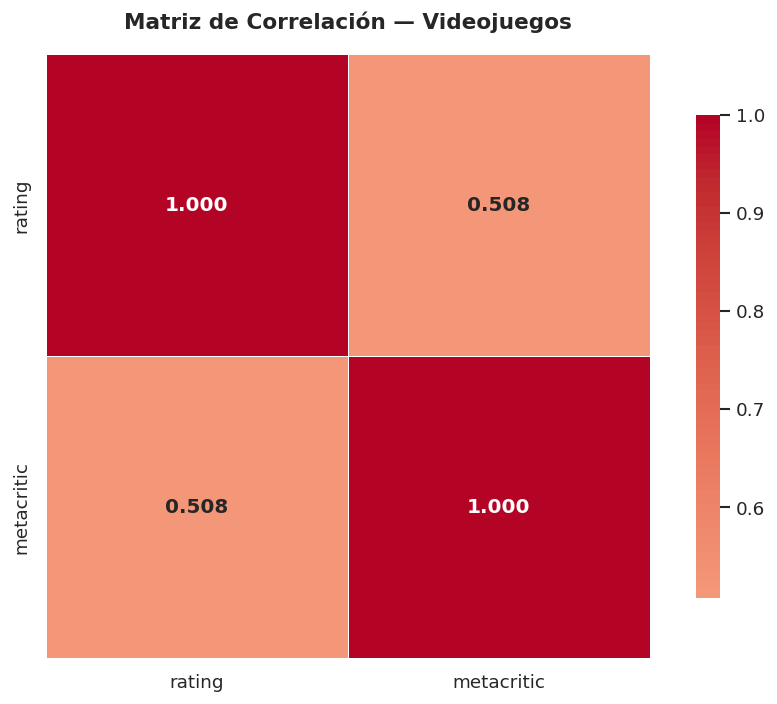


📊 Correlación con rating:
metacritic    0.5079
Name: rating, dtype: float64


In [7]:
# ── CELDA 7: Matriz de correlación ───────────────────────────

corr = df[vars_num].corr()

plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 12, 'weight': 'bold'}
)

plt.title('Matriz de Correlación — Videojuegos',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()

plt.savefig('../data/graficas/eda_correlacion.png',
            dpi=150, bbox_inches='tight')

plt.show()

print("\n📊 Correlación con rating:")
print(corr["rating"].drop("rating").sort_values(ascending=False).round(4))

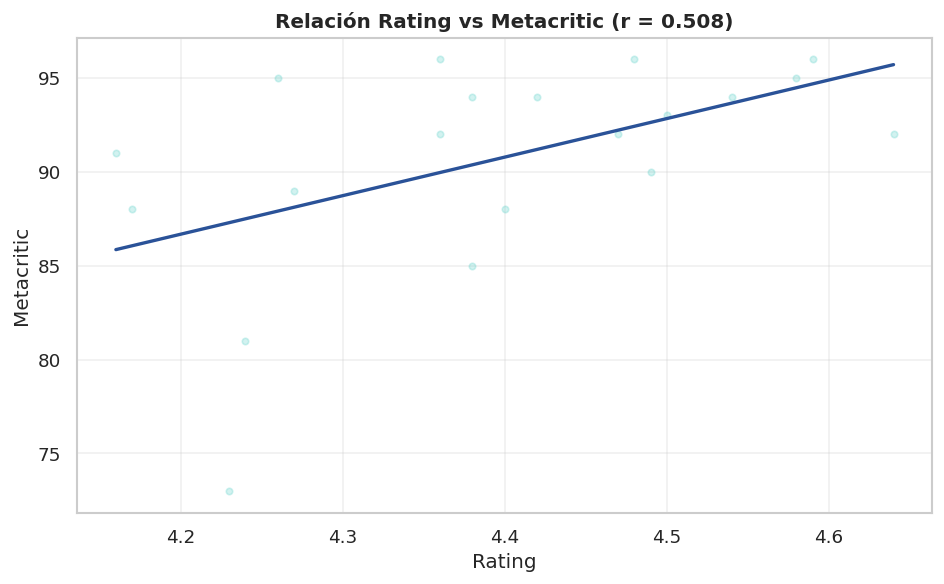

In [8]:
# ── CELDA 8: Scatter plots rating vs metacritic ─────────────

df_clean = df.dropna(subset=["rating", "metacritic"])

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_clean["rating"],
    df_clean["metacritic"],
    alpha=0.25,
    s=15,
    color="#4ecdc4"
)

# Línea de tendencia
z = np.polyfit(df_clean["rating"], df_clean["metacritic"], 1)
p = np.poly1d(z)

xp = np.linspace(df_clean["rating"].min(), df_clean["rating"].max(), 200)

ax.plot(xp, p(xp), color='#2a5298', linewidth=2)

r = df_clean[["rating", "metacritic"]].corr().iloc[0, 1]

ax.set_title(f'Relación Rating vs Metacritic (r = {r:.3f})',
             fontweight='bold')

ax.set_xlabel("Rating")
ax.set_ylabel("Metacritic")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/eda_scatter.png',
            dpi=150, bbox_inches='tight')

plt.show()

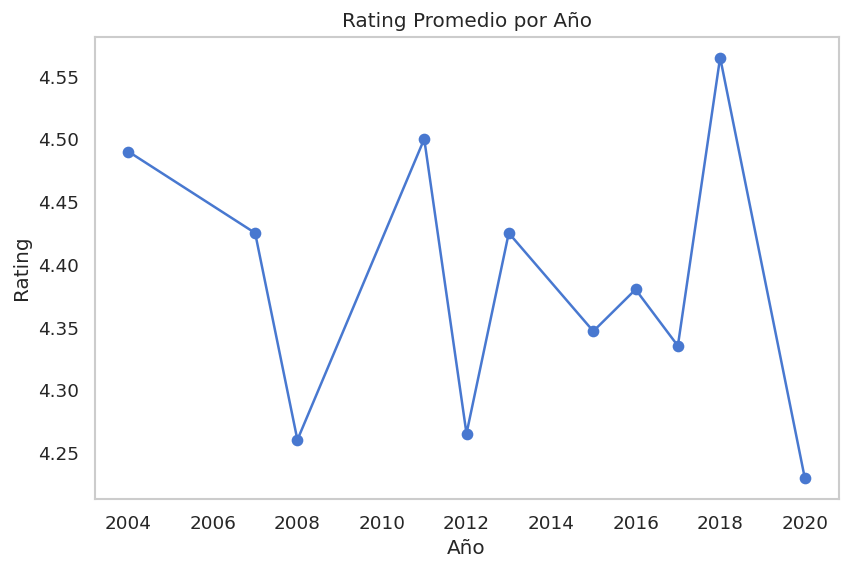

In [9]:
# ── CELDA 9: Evolución temporal ─────────────────────────────

df_time = df.dropna(subset=["fecha_lanzamiento"]).copy()
df_time["Año"] = df_time["fecha_lanzamiento"].dt.year

trend = df_time.groupby("Año")["rating"].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(trend["Año"], trend["rating"], marker="o")

plt.title("Rating Promedio por Año")
plt.xlabel("Año")
plt.ylabel("Rating")

plt.grid()
plt.show()

In [10]:
# ── CELDA 9: Split Train / Test ───────────────────────────────

# Usamos solo datos con metacritic
df_model = df.dropna(subset=['rating', 'metacritic']).copy()

X_simple = df_model[['rating']].values
y        = df_model['metacritic'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 16 muestras (80%)
Test : 4 muestras (20%)


In [11]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(f"\nEcuación : metacritic = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × rating")

Intercepto  β₀ : 5.3647
Coeficiente β₁ : 19.3881

Ecuación : metacritic = 5.365 + 19.388 × rating


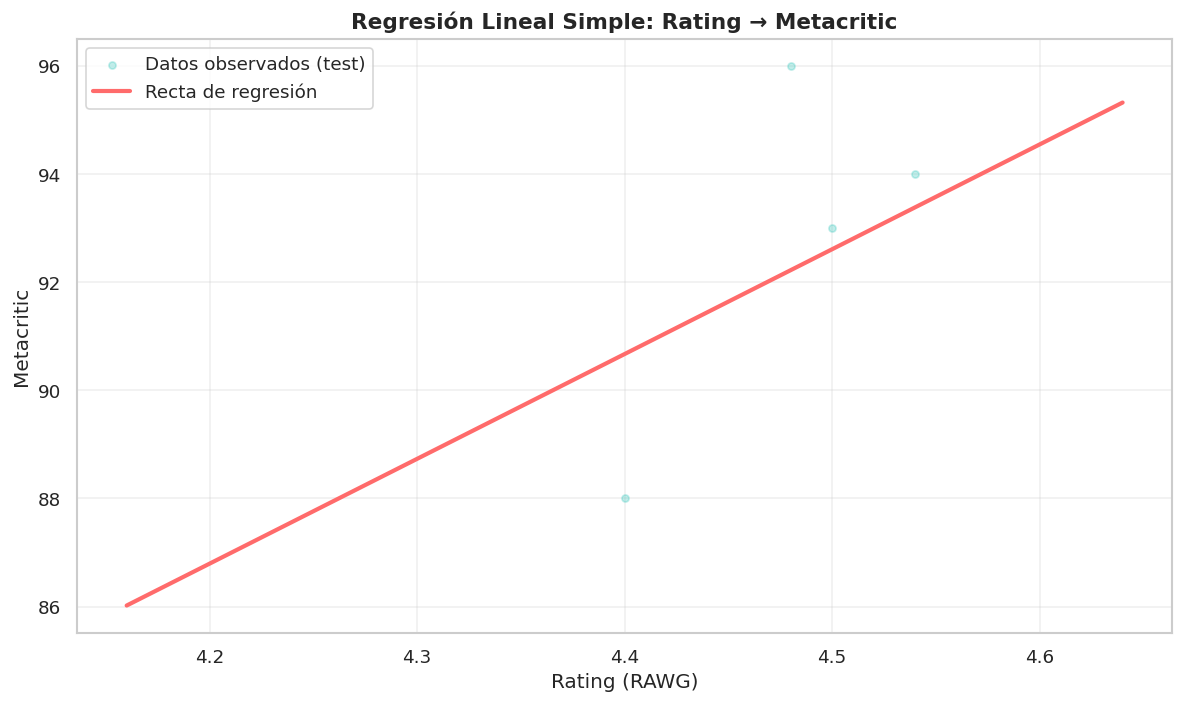

In [12]:
# ── CELDA 11: Recta de regresión ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

# puntos reales
ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')

# línea de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Rating (RAWG)', fontsize=12)
ax.set_ylabel('Metacritic', fontsize=12)
ax.set_title('Regresión Lineal Simple: Rating → Metacritic',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse:.4f}")
print(f"  MAE  (error absoluto medio) : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.3689  (36.89%)
  MSE  (error cuadrático med) : 5.4830
  RMSE (raíz del MSE)         : 2.3416
  MAE  (error absoluto medio) : 1.8629


In [14]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────

import statsmodels.api as sm

X_ols = sm.add_constant(df_model['rating'])
modelo_ols_simple = sm.OLS(df_model['metacritic'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:             metacritic   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     6.256
Date:                Thu, 02 Apr 2026   Prob (F-statistic):             0.0223
Time:                        12:32:28   Log-Likelihood:                -59.771
No. Observations:                  20   AIC:                             123.5
Df Residuals:                      18   BIC:                             125.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4427     36.103      0.012      0.9

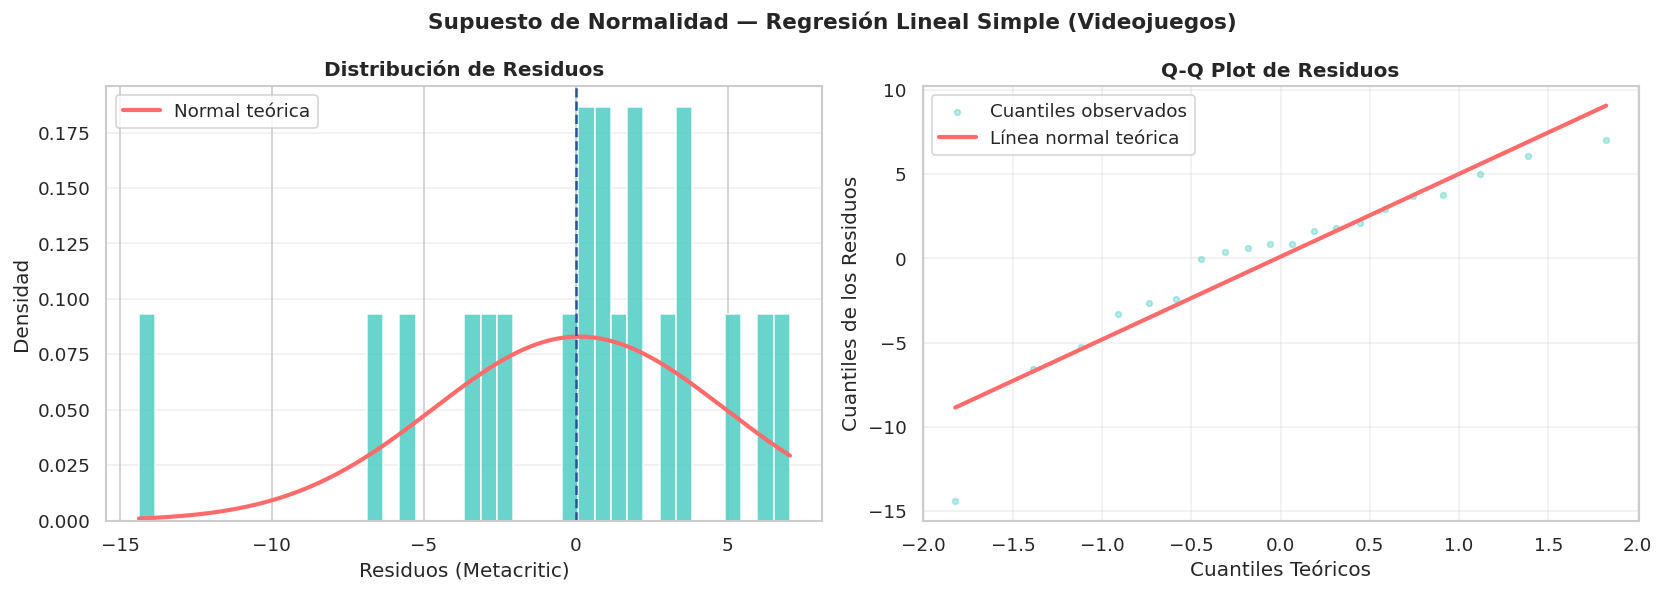


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9068
   p-value       : 0.055390
   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)


In [15]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────

# Predicciones sobre TODO el dataset limpio
y_pred_all = modelo_simple.predict(df_model[['rating']].values)
residuos   = df_model['metacritic'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple (Videojuegos)',
             fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(residuos, bins=40, color='#4ecdc4',
             edgecolor='white', density=True, alpha=0.85)

xr = np.linspace(residuos.min(), residuos.max(), 200)

axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)

axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)

axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (Metacritic)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')

axes[1].plot(osm,
             slope * np.array(osm) + intercept,
             color='#ff6b6b',
             linewidth=2.5,
             label='Línea normal teórica')

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))

stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con datasets grandes esto es normal → revisa el Q-Q plot")

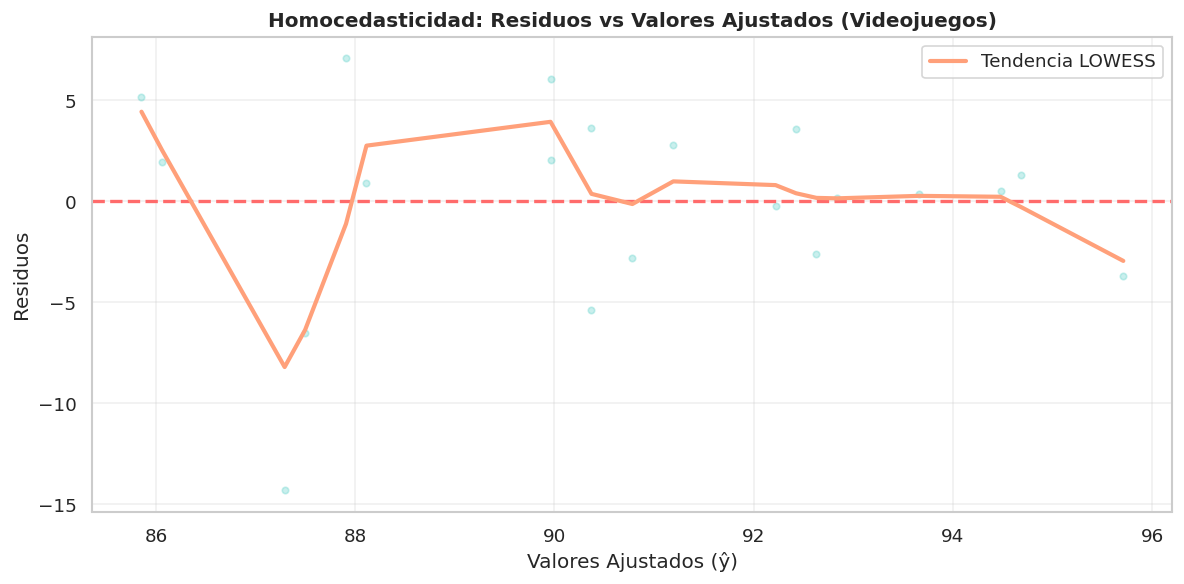


🔬 Test de Breusch-Pagan:
   Estadístico LM : 3.5004
   p-value        : 0.061354
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [16]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────

residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))

plt.scatter(ajustados_ols, residuos_ols,
            alpha=0.30, s=15, color='#4ecdc4')

plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)

plt.plot(lowess[:, 0], lowess[:, 1],
         color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)

plt.title('Homocedasticidad: Residuos vs Valores Ajustados (Videojuegos)',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"\n🔬 Test de Breusch-Pagan:")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)")

In [17]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──

# Crear variable año
df_model_multi = df.dropna(subset=['rating', 'metacritic', 'fecha_lanzamiento']).copy()
df_model_multi['año'] = df_model_multi['fecha_lanzamiento'].dt.year

FEATURES = ['rating', 'año']

X_multi = df_model_multi[FEATURES].values
y       = df_model_multi['metacritic'].values

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀ : {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>10} : {coef:.4f}")

Intercepto  β₀ : 1726.5183
Coeficiente     rating : 17.3064
Coeficiente        año : -0.8504


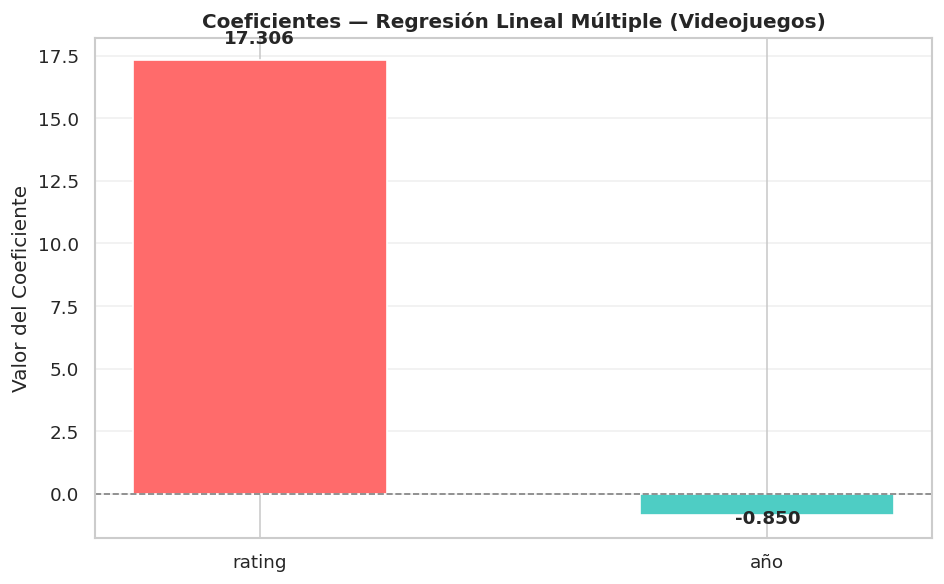

In [18]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Coeficientes — Regresión Lineal Múltiple (Videojuegos)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.5 if coef >= 0 else -0.5
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio) : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : -1.6255  (-162.55%)
  MSE  (error cuadrático med) : 22.8094
  RMSE (raíz del MSE)         : 4.7759
  MAE  (error absoluto medio) : 4.1635


In [20]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────

import statsmodels.api as sm

X_ols_m = sm.add_constant(df_model_multi[FEATURES])
modelo_ols_multi = sm.OLS(df_model_multi['metacritic'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             metacritic   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     7.177
Date:                Thu, 02 Apr 2026   Prob (F-statistic):            0.00550
Time:                        12:32:53   Log-Likelihood:                -56.633
No. Observations:                  20   AIC:                             119.3
Df Residuals:                      17   BIC:                             122.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1120.6640    448.606      2.498      0.0

In [23]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

# Crear año si no existe
df_model['año_lanzamiento'] = pd.to_datetime(
    df_model['fecha_lanzamiento']
).dt.year

FEATURES = ['metacritic', 'año_lanzamiento']

X_vif = df_model[FEATURES].dropna().copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️ Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
       Variable     VIF            Criterio
     metacritic 255.352 ❌ Severa (VIF ≥ 10)
año_lanzamiento 255.352 ❌ Severa (VIF ≥ 10)


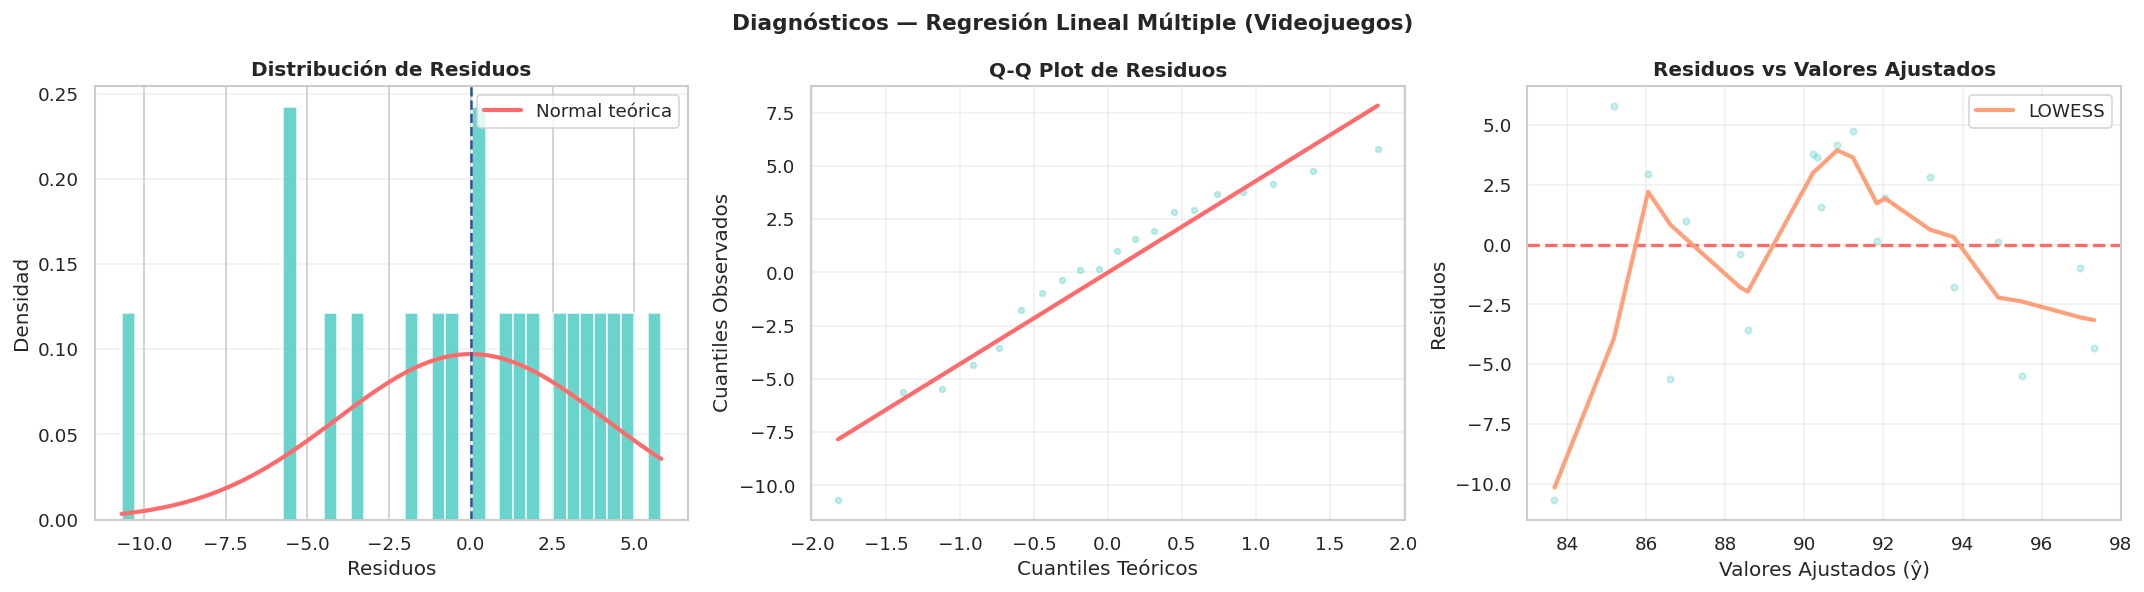


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.221693 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.110620 → ✅ Homocedasticidad OK


In [24]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────

residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Videojuegos)',
             fontsize=13, fontweight='bold')

# ── 1. Histograma de residuos
axes[0].hist(residuos_m, bins=40,
             color='#4ecdc4',
             edgecolor='white',
             density=True,
             alpha=0.85)

xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)

axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)

axes[0].axvline(0, color='#2a5298', linestyle='--')

axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── 2. Q-Q Plot
(osm, osr), (slope, intercept, _) = stats.probplot(residuos_m, dist='norm')

axes[1].scatter(osm, osr,
                alpha=0.35,
                s=12,
                color='#4ecdc4')

axes[1].plot(
    osm,
    slope * np.array(osm) + intercept,
    color='#ff6b6b',
    linewidth=2.5
)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── 3. Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m,
                alpha=0.30,
                s=15,
                color='#4ecdc4')

axes[2].axhline(0, color='#ff6b6b',
                linestyle='--',
                linewidth=2)

# Línea LOWESS
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)

axes[2].plot(
    lowess_m[:, 0],
    lowess_m[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='LOWESS'
)

axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/diagnosticos_multi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ── TESTS ESTADÍSTICOS

# Shapiro-Wilk (normalidad)
muestra_m = (
    residuos_m if len(residuos_m) <= 5000
    else np.random.default_rng(42).choice(residuos_m, 5000, replace=False)
)

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)

# Breusch-Pagan (homocedasticidad)
lm_m, lm_p_m, _, _ = het_breuschpagan(
    modelo_ols_multi.resid,
    modelo_ols_multi.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}")

print("\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}")

In [25]:
# ── CELDA 22: Comparación final de modelos ───────────────────

comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple', 'Regresión Múltiple'],
    
    'Variables': [
        'rating',
        'rating + anio'
    ],
    
    'R²': [
        round(r2, 4),
        round(r2_m, 4)
    ],
    
    'R² Aj.': [
        round(modelo_ols_simple.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    
    'RMSE': [
        round(rmse, 4),
        round(rmse_m, 4)
    ],
    
    'MAE': [
        round(mae, 4),
        round(mae_m, 4)
    ],
    
    'AIC': [
        round(modelo_ols_simple.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    
    'BIC': [
        round(modelo_ols_simple.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS (VIDEOJUEGOS)")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)

print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad")

              COMPARACIÓN DE MODELOS (VIDEOJUEGOS)
            Modelo     Variables      R²  R² Aj.   RMSE    MAE    AIC    BIC
  Regresión Simple        rating  0.3689  0.2167 2.3416 1.8629 123.54 125.53
Regresión Múltiple rating + anio -1.6255  0.3940 4.7759 4.1635 119.27 122.25

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad


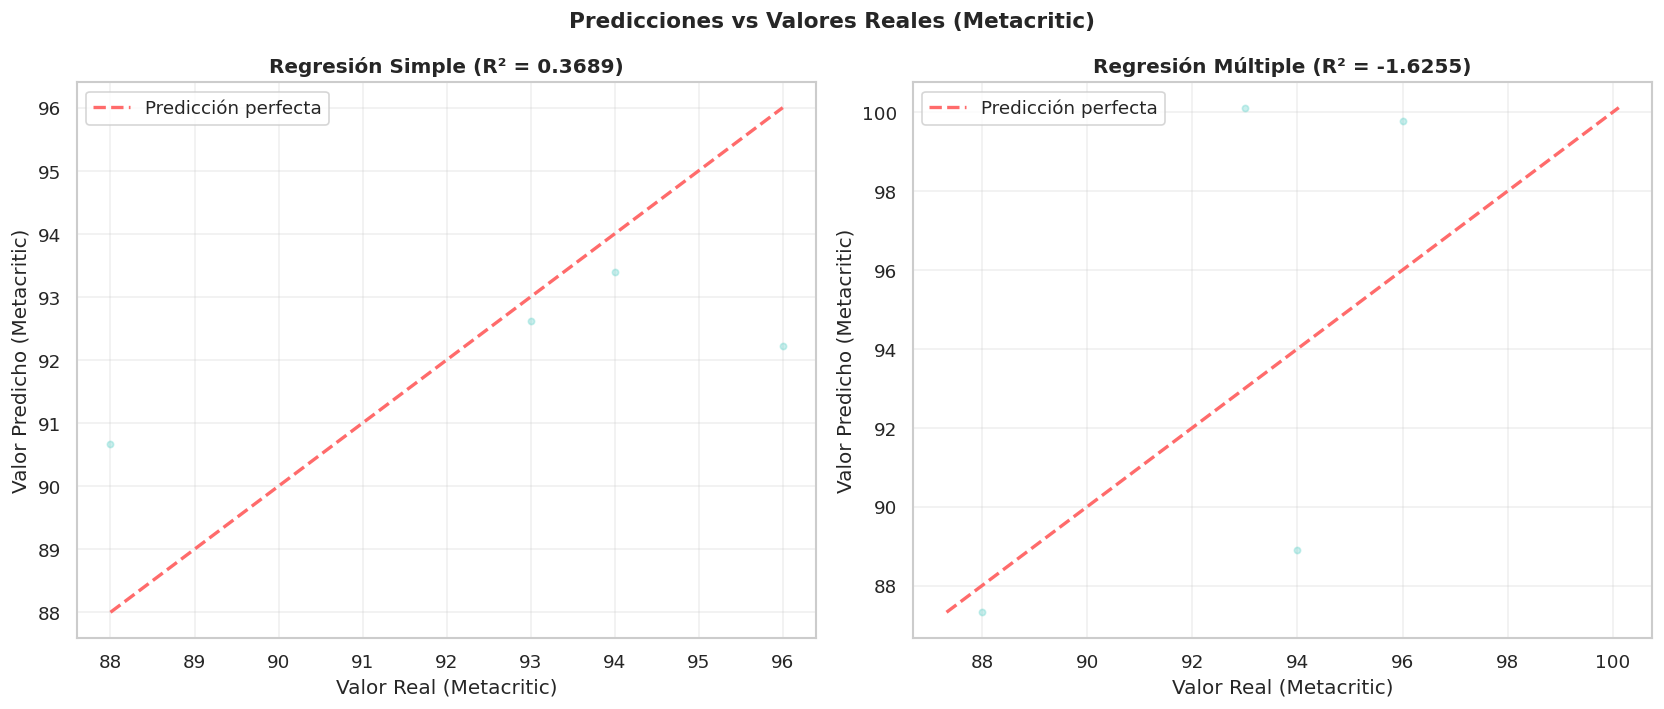

In [26]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('Predicciones vs Valores Reales (Metacritic)',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):

    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(
        y_real,
        y_pred,
        alpha=0.30,
        s=14,
        color='#4ecdc4'
    )

    # Línea de predicción perfecta
    ax.plot(
        [minval, maxval],
        [minval, maxval],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})',
                 fontweight='bold')

    ax.set_xlabel('Valor Real (Metacritic)')
    ax.set_ylabel('Valor Predicho (Metacritic)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/predicciones_vs_reales.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()